In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
conn = sqlite3.connect('cs430_synth.db')
cursor = conn.cursor()

In [2]:
df = pd.read_sql_query('''
                        SELECT * FROM purchase
                        ''', conn)
df.head()

,PurchaseID,UserID,TimeDate,PaymentID,Location,Category,Subcategory
0,1,22,2025-08-06 22:53:39,1,West Willie,transportation,tolls
1,2,5,2025-04-04 22:53:39,2,Stephenmouth,food,restaurants
2,3,5,2025-03-12 22:53:39,3,North Angelamouth,miscellaneous,school supplies
3,4,8,2025-05-09 22:53:39,4,New Nicholas,transportation,maintenence
4,5,6,2025-02-16 22:53:39,5,North Jessicaburgh,food,restaurants


In [3]:
df = df.set_index('PurchaseID')

In [4]:
df.head()

,UserID,TimeDate,PaymentID,Location,Category,Subcategory
PurchaseID,,,,,,
1,22,2025-08-06 22:53:39,1,West Willie,transportation,tolls
2,5,2025-04-04 22:53:39,2,Stephenmouth,food,restaurants
3,5,2025-03-12 22:53:39,3,North Angelamouth,miscellaneous,school supplies
4,8,2025-05-09 22:53:39,4,New Nicholas,transportation,maintenence
5,6,2025-02-16 22:53:39,5,North Jessicaburgh,food,restaurants


In [5]:
df_uid = df.query('UserID == 45')

In [109]:
df_uid = df_uid.sort_values(by='TimeDate', ascending=False)

<BarContainer object of 48 artists>

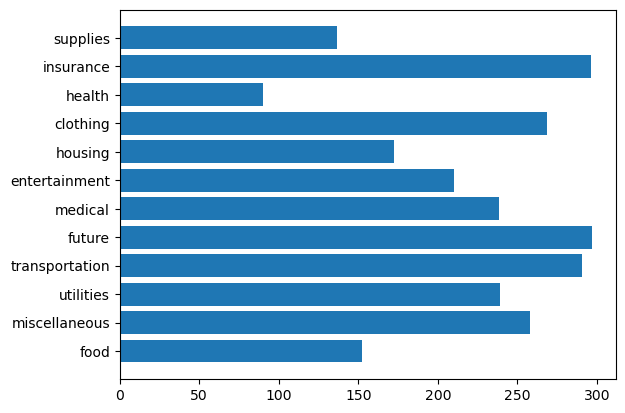

In [8]:
userid = 20

df = pd.read_sql_query(f'''
                        SELECT Users.Name, Purchase.TimeDate, Payments.Amount, Purchase.Category, Purchase.Subcategory  
                        FROM Users
                        JOIN Purchase on Users.UserID = Purchase.UserID
                        JOIN Payments on Purchase.PaymentID = Payments.PaymentID
                        WHERE Users.UserID = {userid}
                        ORDER BY Purchase.TimeDate ASC
                        ''', conn)
    
df['TimeDate'] = pd.to_datetime(df['TimeDate'])

df['TimeDate'] = df['TimeDate'].dt.floor('D')

df['running_total'] = df['Amount'].cumsum()

#df_pivot = df.pivot_table(index = df.index, columns = 'Category', values = 'Amount')
#print(df_pivot.head())

plt.barh(y = df['Category'], width = df['Amount']) 

<BarContainer object of 5 artists>

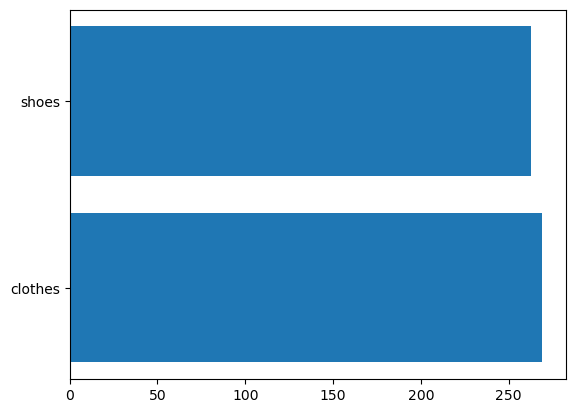

In [125]:
df_pivot = df.query("Category == 'clothing'")
plt.barh(y = df_pivot['Subcategory'], width = df_pivot['Amount']) 

In [22]:
userid = 20
category_bar_df = pd.read_sql_query(f'''
                  SELECT Purchase.Category, Purchase.Subcategory, Payments.Amount
                  FROM Purchase
                  JOIN Payments ON Purchase.PaymentID = Payments.PaymentID
                  WHERE Purchase.UserID = {userid}
                  GROUP BY Purchase.Subcategory
                  ORDER BY Purchase.Category
                  ''', conn)

fig = px.bar(category_bar_df, x = "Category", y = "Amount", color = "Subcategory")
fig.show()

In [70]:
spending_time = pd.read_sql_query(f'''
                SELECT Purchase.Category, Purchase.Subcategory, Payments.Amount, Purchase.TimeDate
                FROM Purchase
                JOIN Payments ON Purchase.PaymentID = Payments.PaymentID
                WHERE Purchase.UserID = {userid}
                ORDER BY Purchase.Category, Purchase.TimeDate
                                    ''', conn)

spending_time["Running"] = spending_time.groupby("Category")["Amount"].cumsum()

print(spending_time)

fig = px.line(spending_time, x="TimeDate", y="Running", color="Category")
fig.show()

          Category     Subcategory  Amount             TimeDate  Running
0         clothing         clothes  268.92  2025-04-01 22:53:39   268.92
1         clothing         clothes  194.04  2025-04-05 22:53:39   462.96
2         clothing         clothes  199.60  2025-05-07 22:53:39   662.56
3         clothing           shoes  262.81  2025-07-20 22:53:39   925.37
4         clothing         clothes   29.41  2025-08-31 22:53:39   954.78
5    entertainment          events   23.13  2025-02-10 22:53:39    23.13
6    entertainment         hobbies  210.31  2025-06-19 22:53:39   233.44
7    entertainment    games/movies   75.25  2025-11-05 22:53:39   308.69
8             food       groceries  152.51  2024-11-17 22:53:39   152.51
9             food       groceries  113.45  2024-12-02 22:53:39   265.96
10            food       groceries  146.59  2025-03-02 22:53:39   412.55
11            food       groceries   55.53  2025-07-17 22:53:39   468.08
12          future  debt repayment  237.24  2025-01

In [69]:
category = 'transportation'

spending_time = pd.read_sql_query(f'''
                SELECT Purchase.Category, Purchase.Subcategory, Payments.Amount, Purchase.TimeDate
                FROM Purchase
                JOIN Payments ON Purchase.PaymentID = Payments.PaymentID
                WHERE Purchase.UserID = {userid} AND Purchase.Category = '{category}'
                ORDER BY Purchase.Category, Purchase.TimeDate
                                    ''', conn)

#spending_time["Running"] = spending_time.groupby(["Category", "Subcategory"])["Amount"].cumsum()

print(spending_time)

fig = px.scatter(spending_time, x="TimeDate", y="Amount", color="Subcategory")
fig.show()

         Category Subcategory  Amount             TimeDate
0  transportation   insurance  109.91  2024-12-28 22:53:39
1  transportation   insurance   87.89  2025-01-15 22:53:39
2  transportation     parking  290.85  2025-01-28 22:53:39
3  transportation     parking  171.64  2025-03-08 22:53:39
4  transportation         gas  103.90  2025-05-02 22:53:39
